# Friendly-Route — sandbox

Quick experimentation notebook. The full pipeline in one place.


In [1]:
import osmnx as ox

from config import CRITERIA, NETWORK_TYPE, PLACE_NAME, nodes_dict
from src.graph.build import StreetGraph
from src.graph.routing import RouteGraph
from src.maps.google_maps import build_google_maps_url
from src.visualization.plot import RoutePlotter

ox.settings.use_cache = True
ox.settings.log_console = True

In [2]:
# ── Build street graph ─────────────────────────────────────────────────────────
sg = StreetGraph(PLACE_NAME, NETWORK_TYPE)
sg.snap_nodes(nodes_dict)

print(f"Nodes snapped: {sg.nodes_name_id}")

Nodes snapped: {'Zamorano': 1, 'TEO': 12796417696, 'Reg_Civil': 12796417697, 'Ram_lav': 12796417698, 'La_pizarra': 12796417699, 'Malu': -1}


In [3]:
# ── Compute paths & find optimal route ────────────────────────────────────────
rg = RouteGraph(sg, criteria=CRITERIA)
rg.compute_paths()
rg.find_optimal()

id_to_name = {v: k for k, v in sg.nodes_name_id.items()}
order_labels = " → ".join(id_to_name.get(n, str(n)) for n in rg.best_order)

print(f"Optimal order:   {order_labels}")
print(f"Total distance:  {rg.best_distance} km")

Optimal order:   Zamorano → Reg_Civil → TEO → Ram_lav → La_pizarra → Malu
Total distance:  10.6 km


/opt/miniconda3/envs/friendly-route/lib/python3.10/site-packages/osmnx/plot.py:351: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(od_x, od_y, s=orig_dest_size, c=route_color, alpha=route_alpha, edgecolor="none")


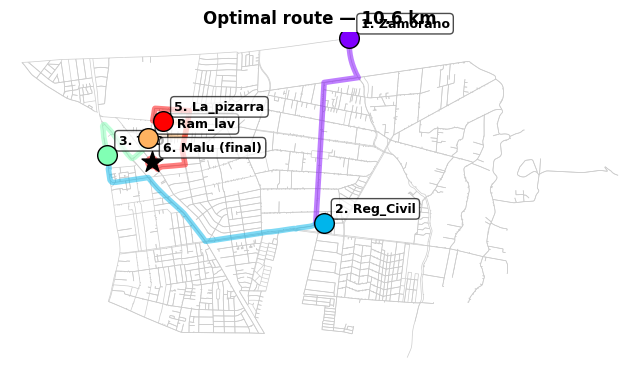

In [4]:
# ── Plot ───────────────────────────────────────────────────────────────────────
plotter = RoutePlotter(rg)
plotter.plot()

In [5]:
# ── Google Maps URL ────────────────────────────────────────────────────────────
url = build_google_maps_url(rg)
print(url)

https://www.google.com/maps/dir/?api=1&origin=-33.42897659999999,-70.5392776&destination=-33.44312863162667,-70.56628771285683&travelmode=driving&waypoints=-33.450107597659006,-70.54277019976271|-33.442338126896296,-70.5723818547006|-33.44040753163625,-70.56685861596492|-33.43846556157411,-70.56475016828233
